In [ ]:
import pandas as pd

# Load datasets
deliveries = pd.read_csv("/content/deliveries.csv")
matches = pd.read_csv("/content/matches.csv")

# Shape
print("Deliveries shape:", deliveries.shape)
print("Matches shape:", matches.shape)

# Columns
print("\nDeliveries columns:")
print(deliveries.columns)

print("\nMatches columns:")
print(matches.columns)

# Preview
deliveries.head()

Deliveries shape: (260920, 17)
Matches shape: (1095, 20)

Deliveries columns:
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

Matches columns:
Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
deliveries = deliveries[[
    'match_id','inning','batting_team','bowling_team',
    'over','ball','total_runs','is_wicket'
]]

In [ ]:
matches = matches[[
    'id','winner','team1','team2','target_runs'
]]

In [ ]:
# Merge datasets
data= deliveries.merge(matches, left_on='match_id', right_on='id')
data.rename(columns={'target_runs':'target'},inplace=True)

# Check shape
print(data.shape)

# Preview
data.head()

(260920, 13)


,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket,id,winner,team1,team2,target
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,1,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,1,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,0,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0


In [ ]:
data = data[data['inning'] == 2]
data=data[data['winner'].notnull()]
data['result'] = (data['batting_team'].str.strip() == data['winner'].str.strip()).astype(int)


# Check shape
print(data.shape)

# Preview
data.head()

(125714, 14)


,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket,id,winner,team1,team2,target,result
124,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,1,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0,0
125,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,2,1,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0,0
126,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,3,0,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0,0
127,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,4,1,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0,0
128,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,5,1,0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,223.0,0


In [ ]:
# Check
data[['batting_team', 'winner', 'result']].head()

,batting_team,winner,result
124,Royal Challengers Bangalore,Kolkata Knight Riders,0
125,Royal Challengers Bangalore,Kolkata Knight Riders,0
126,Royal Challengers Bangalore,Kolkata Knight Riders,0
127,Royal Challengers Bangalore,Kolkata Knight Riders,0
128,Royal Challengers Bangalore,Kolkata Knight Riders,0


In [ ]:
data['current_score'] = data.groupby(['match_id','inning'])['total_runs'].cumsum()

In [ ]:
data['wickets_fallen'] = data.groupby(['match_id','inning'])['is_wicket'].cumsum()

In [ ]:
data['wickets_remaining'] = 10 - data['wickets_fallen']

In [ ]:
data['overs'] = data['over'] + data['ball']/6

In [ ]:
data['balls_remaining'] = 120 - (data['over']*6 + data['ball'])


In [ ]:
data['runs_required'] = data['target'] - data['current_score']

In [ ]:
data['current_run_rate'] = data['current_score'] / data['overs'].replace(0,1)

In [ ]:
data['required_run_rate'] = data['runs_required'] / (data['balls_remaining'].replace(0,1))*6

In [ ]:
data['pressure'] = data['required_run_rate'] - data['current_run_rate']

In [ ]:
def get_phase(over):
    if over < 6:
        return 'powerplay'
    elif over < 15:
        return 'middle'
    else:
        return 'death'

data['match_phase'] = data['over'].apply(get_phase)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125714 entries, 124 to 260919
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           125714 non-null  int64  
 1   inning             125714 non-null  int64  
 2   batting_team       125714 non-null  object 
 3   bowling_team       125714 non-null  object 
 4   over               125714 non-null  int64  
 5   ball               125714 non-null  int64  
 6   total_runs         125714 non-null  int64  
 7   is_wicket          125714 non-null  int64  
 8   id                 125714 non-null  int64  
 9   winner             125714 non-null  object 
 10  team1              125714 non-null  object 
 11  team2              125714 non-null  object 
 12  target             125714 non-null  float64
 13  result             125714 non-null  int64  
 14  current_score      125714 non-null  int64  
 15  wickets_fallen     125714 non-null  int64  
 16  wicke

In [ ]:
data.head()

,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket,id,winner,...,current_score,wickets_fallen,wickets_remaining,overs,balls_remaining,runs_required,current_run_rate,required_run_rate,pressure,match_phase
124,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,1,0,335982,Kolkata Knight Riders,...,1,0,10,0.166667,119,222.0,6.0,11.193277,5.193277,powerplay
125,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,2,1,0,335982,Kolkata Knight Riders,...,2,0,10,0.333333,118,221.0,6.0,11.237288,5.237288,powerplay
126,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,3,0,0,335982,Kolkata Knight Riders,...,2,0,10,0.500000,117,221.0,4.0,11.333333,7.333333,powerplay
127,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,4,1,0,335982,Kolkata Knight Riders,...,3,0,10,0.666667,116,220.0,4.5,11.379310,6.879310,powerplay
128,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,5,1,0,335982,Kolkata Knight Riders,...,4,0,10,0.833333,115,219.0,4.8,11.426087,6.626087,powerplay


In [ ]:
features = [
    'batting_team','bowling_team',
    'current_score','wickets_fallen','wickets_remaining',
    'current_run_rate','required_run_rate','pressure',
    'balls_remaining','runs_required','match_phase',
    'result','target'
]

In [ ]:
model_data=data[features]

In [ ]:
model_data.head(10)

,batting_team,bowling_team,current_score,wickets_fallen,wickets_remaining,current_run_rate,required_run_rate,pressure,balls_remaining,runs_required,match_phase,result,target
124,Royal Challengers Bangalore,Kolkata Knight Riders,1,0,10,6.000000,11.193277,5.193277,119,222.0,powerplay,0,223.0
125,Royal Challengers Bangalore,Kolkata Knight Riders,2,0,10,6.000000,11.237288,5.237288,118,221.0,powerplay,0,223.0
126,Royal Challengers Bangalore,Kolkata Knight Riders,2,0,10,4.000000,11.333333,7.333333,117,221.0,powerplay,0,223.0
127,Royal Challengers Bangalore,Kolkata Knight Riders,3,0,10,4.500000,11.379310,6.879310,116,220.0,powerplay,0,223.0
128,Royal Challengers Bangalore,Kolkata Knight Riders,4,0,10,4.800000,11.426087,6.626087,115,219.0,powerplay,0,223.0
129,Royal Challengers Bangalore,Kolkata Knight Riders,4,0,10,4.000000,11.526316,7.526316,114,219.0,powerplay,0,223.0
130,Royal Challengers Bangalore,Kolkata Knight Riders,4,0,10,3.428571,11.628319,8.199747,113,219.0,powerplay,0,223.0
131,Royal Challengers Bangalore,Kolkata Knight Riders,4,1,9,3.428571,11.628319,8.199747,113,219.0,powerplay,0,223.0
132,Royal Challengers Bangalore,Kolkata Knight Riders,4,1,9,3.000000,11.732143,8.732143,112,219.0,powerplay,0,223.0
133,Royal Challengers Bangalore,Kolkata Knight Riders,8,1,9,5.333333,11.621622,6.288288,111,215.0,powerplay,0,223.0


In [ ]:
model_data=model_data.dropna()
model_data=pd.get_dummies(model_data)

In [ ]:
model_data.shape

(125714, 51)

In [ ]:
X = model_data.drop('result',axis=1)
y = model_data['result']

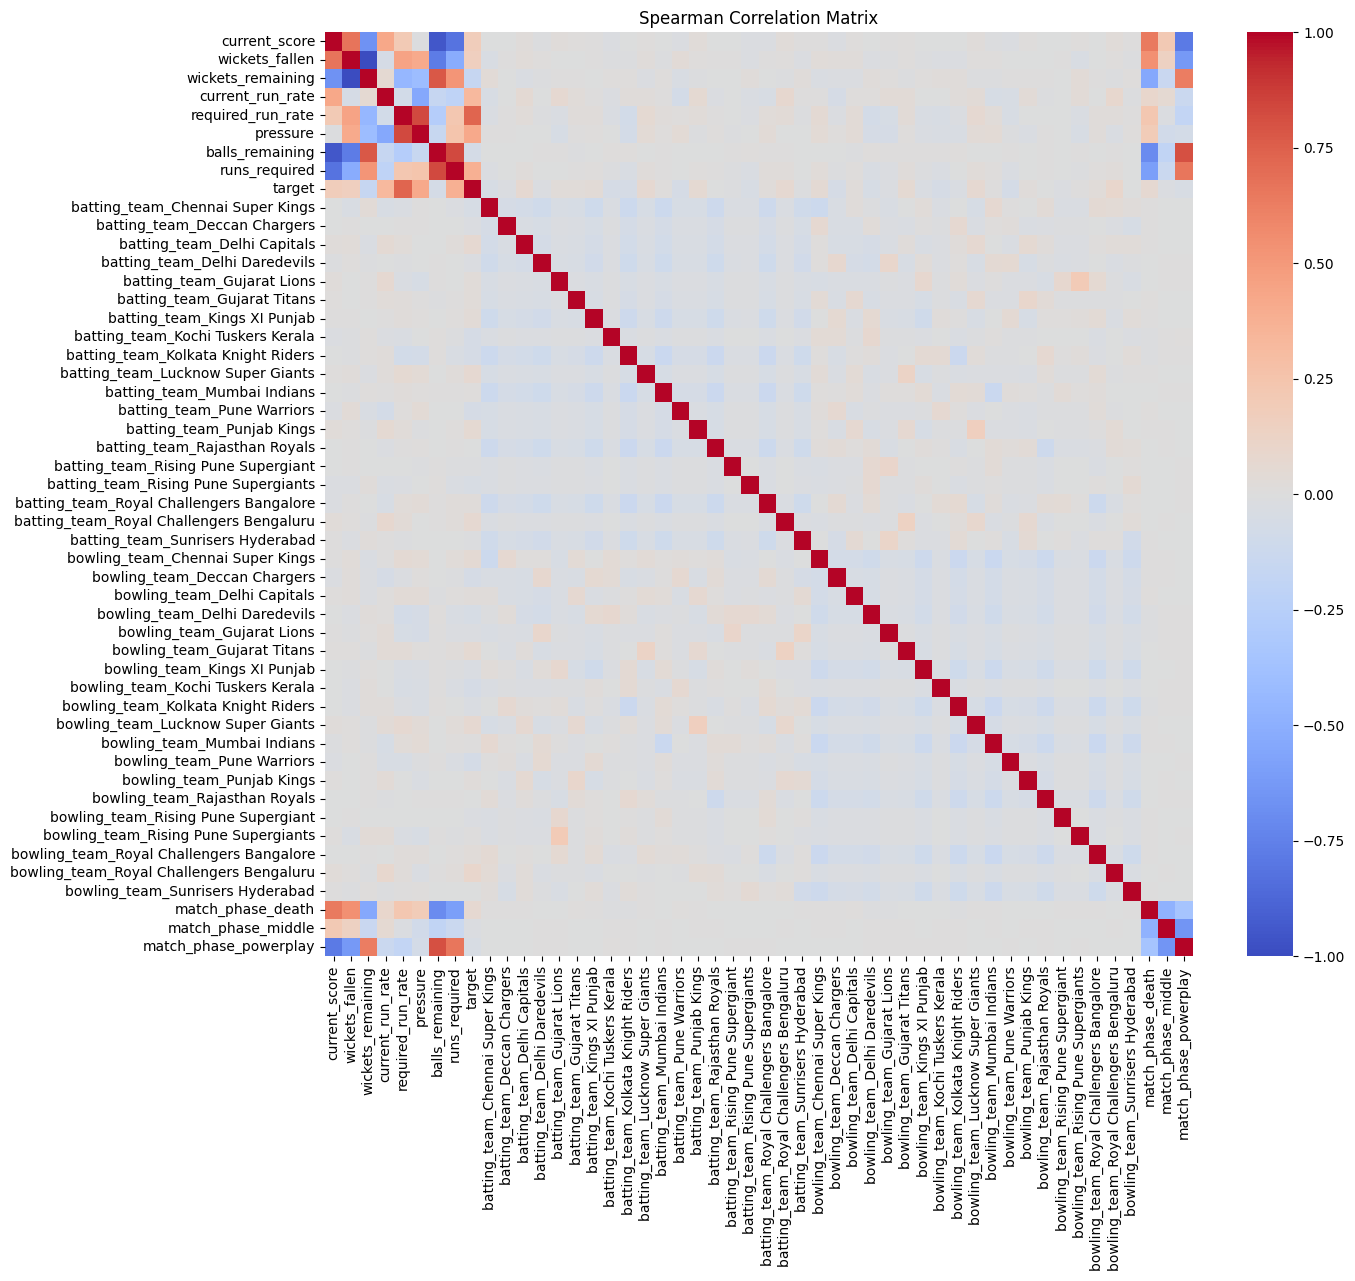

Highly correlated features (|Spearman| > 0.75):
['wickets_remaining', 'pressure', 'balls_remaining', 'runs_required', 'match_phase_powerplay']


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Spearman correlation ---
corr_matrix = X.corr(method='spearman')

# --- 2. Heatmap plot ---
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

# --- 3. High correlation detect (ABS + upper triangle) ---
corr_abs = corr_matrix.abs()

upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

high_corr = [col for col in upper.columns if any(upper[col] > 0.75)]

print("Highly correlated features (|Spearman| > 0.75):")
print(high_corr)

In [ ]:
X = X.drop(columns=['wickets_remaining', 'pressure', 'balls_remaining', 'runs_required', 'match_phase_powerplay'])

In [ ]:
X.shape

(125714, 45)

In [ ]:
from sklearn.model_selection import train_test_split

# Unique match IDs
match_ids = data['match_id'].unique()

# Split (80% train, 20% test)
train_ids, test_ids = train_test_split(match_ids, test_size=0.2, random_state=42)

# Create datasets
train_data = model_data[data['match_id'].isin(train_ids)]
test_data = model_data[data['match_id'].isin(test_ids)]

# Features & target
X_train = train_data.drop('result', axis=1)
y_train = train_data['result']

X_test = test_data.drop('result', axis=1)
y_test = test_data['result']

In [ ]:
groups = data.loc[X_train.index, 'match_id']

In [ ]:
print(X_train.shape,
X_test.shape,
y_test.shape,
y_train.shape)

(100925, 50) (24789, 50) (24789,) (100925,)


Logistic Regression


In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.linear_model import LogisticRegression

# Groups (match-wise)
groups = data.loc[X_train.index, 'match_id']

# Param grid
param_grid = {'C': [0.01, 0.1, 0.5, 1, 2]}

# CV
gkf = GroupKFold(n_splits=3)

# GridSearch
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=gkf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train, groups=groups)

print("Best Params:", grid_lr.best_params_)

Best Params: {'C': 0.01}


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_prob_lr))
print("Log Loss:", log_loss(y_test, y_prob_lr))

Accuracy: 0.8108838597765138
AUC: 0.8988344919695539
Log Loss: 0.40570521413152066


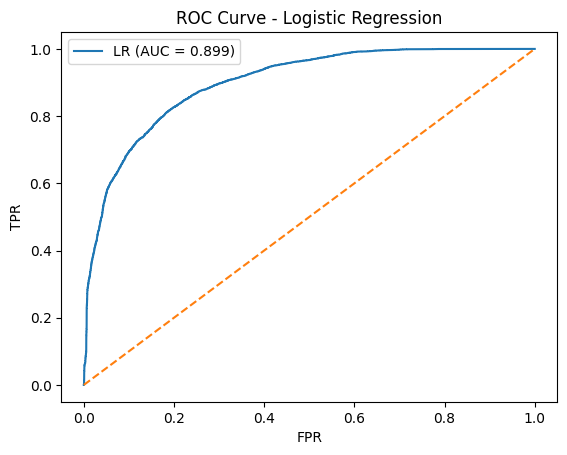

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

plt.figure()
plt.plot(fpr, tpr, label=f'LR (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

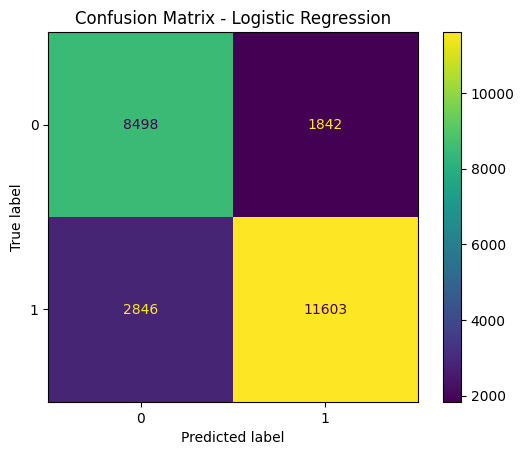

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

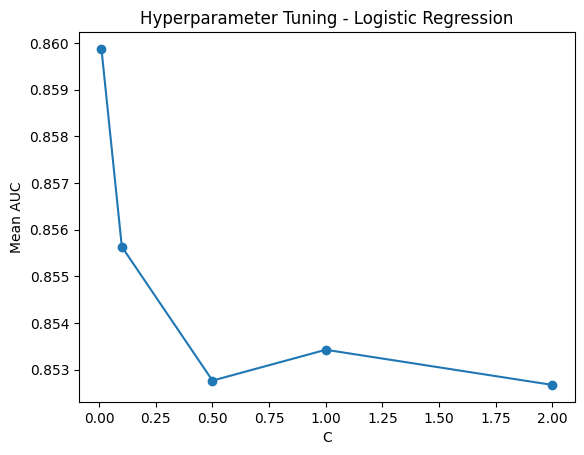

In [ ]:
results_lr = pd.DataFrame(grid_lr.cv_results_)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(results_lr['param_C'], results_lr['mean_test_score'], marker='o')

plt.xlabel("C")
plt.ylabel("Mean AUC")
plt.title("Hyperparameter Tuning - Logistic Regression")

plt.show()

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold

# Param grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

# CV
gkf = GroupKFold(n_splits=3)

# GridSearch
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=gkf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train, groups=groups)

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("Log Loss:", log_loss(y_test, y_prob_rf))

Accuracy: 0.811448626406874
AUC: 0.9051810389453574
Log Loss: 0.4012730174309686


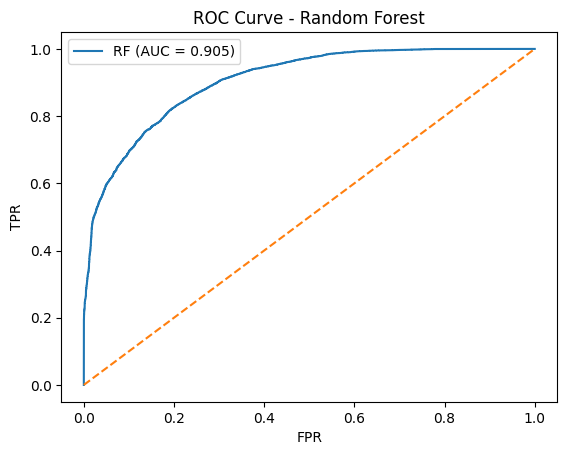

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr, label=f'RF (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

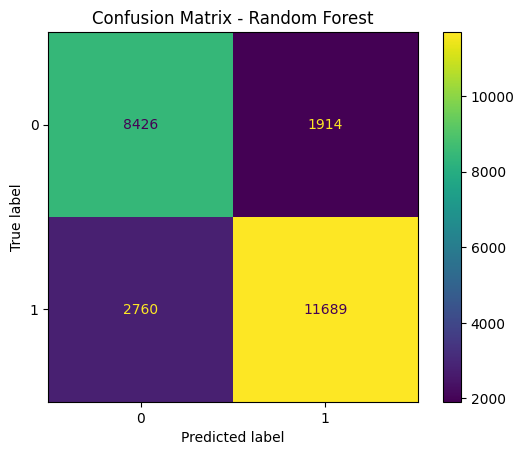

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

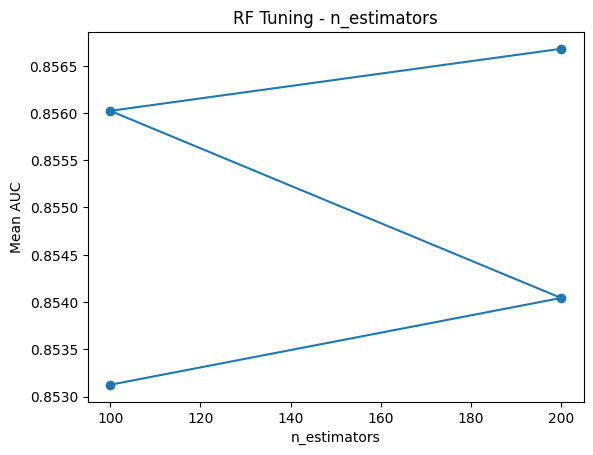

In [ ]:
results_rf = pd.DataFrame(grid_rf.cv_results_)

plt.figure()
plt.plot(results_rf['param_n_estimators'], results_rf['mean_test_score'], marker='o')

plt.xlabel("n_estimators")
plt.ylabel("Mean AUC")
plt.title("RF Tuning - n_estimators")

plt.show()

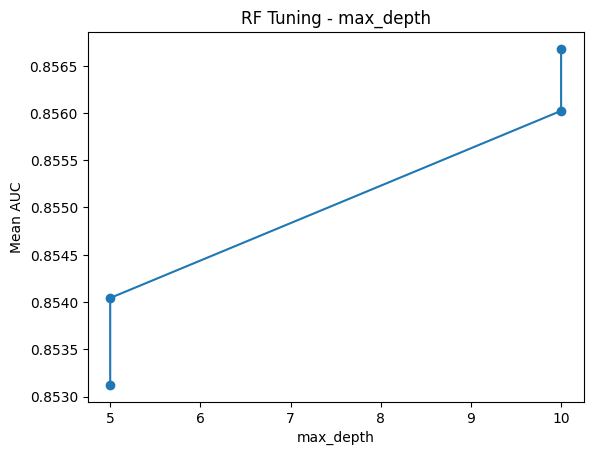

In [ ]:
plt.figure()
plt.plot(results_rf['param_max_depth'], results_rf['mean_test_score'], marker='o')
plt.xlabel("max_depth")
plt.ylabel("Mean AUC")
plt.title("RF Tuning - max_depth")
plt.show()

gradient boosting


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold

# Param grid
param_grid_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1]
}

# CV
gkf = GroupKFold(n_splits=3)

# GridSearch
grid_gb = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid_gb,
    cv=gkf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train, groups=groups)

print("Best Params:", grid_gb.best_params_)

Best Params: {'learning_rate': 0.05, 'n_estimators': 100}


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("AUC:", roc_auc_score(y_test, y_prob_gb))
print("Log Loss:", log_loss(y_test, y_prob_gb))

Accuracy: 0.8191536568639316
AUC: 0.9126306787308874
Log Loss: 0.39781677104984775


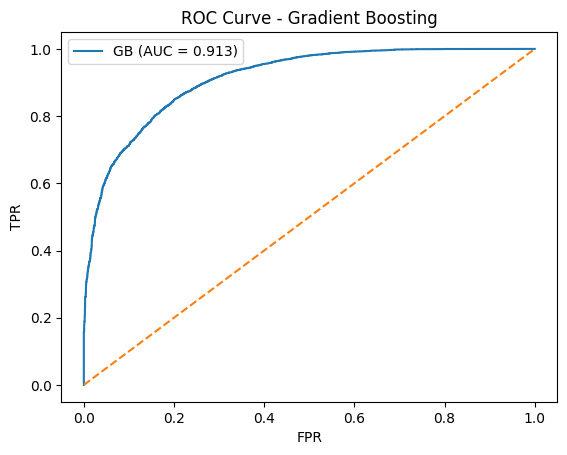

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
auc_score = roc_auc_score(y_test, y_prob_gb)

plt.figure()
plt.plot(fpr, tpr, label=f'GB (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

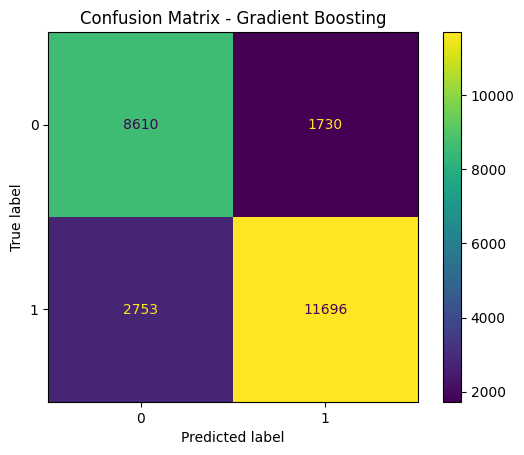

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

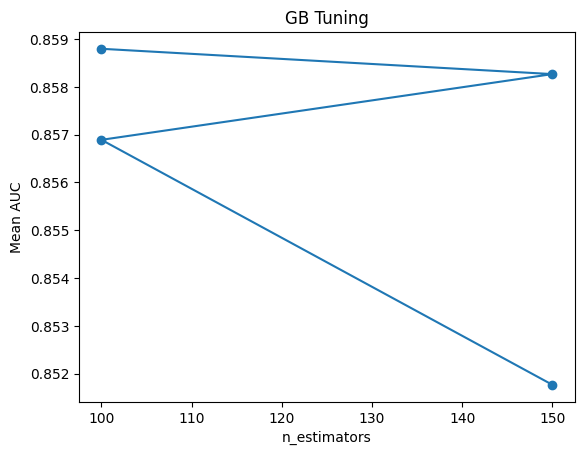

In [ ]:
results_gb = pd.DataFrame(grid_gb.cv_results_)

plt.figure()
plt.plot(results_gb['param_n_estimators'], results_gb['mean_test_score'], marker='o')

plt.xlabel("n_estimators")
plt.ylabel("Mean AUC")
plt.title("GB Tuning")

plt.show()

xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gkf = GroupKFold(n_splits=3)

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', use_label_encoder=False),
    param_grid_xgb,
    cv=gkf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train, groups=groups)

print("Best Params:", grid_xgb.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:58:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_prob_xgb))
print("Log Loss:", log_loss(y_test, y_prob_xgb))

Accuracy: 0.8222598733309129
AUC: 0.9104297440219604
Log Loss: 0.38995530190458877


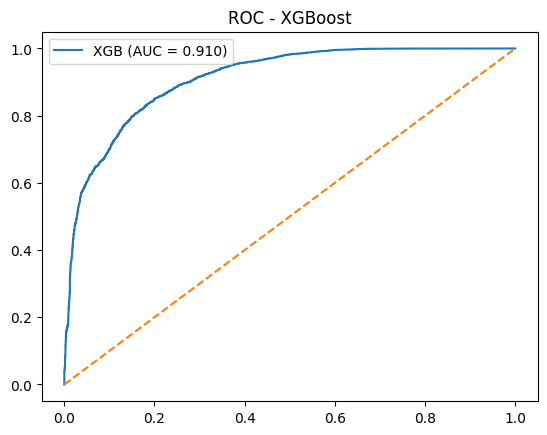

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
auc_score = roc_auc_score(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f'XGB (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC - XGBoost")
plt.show()

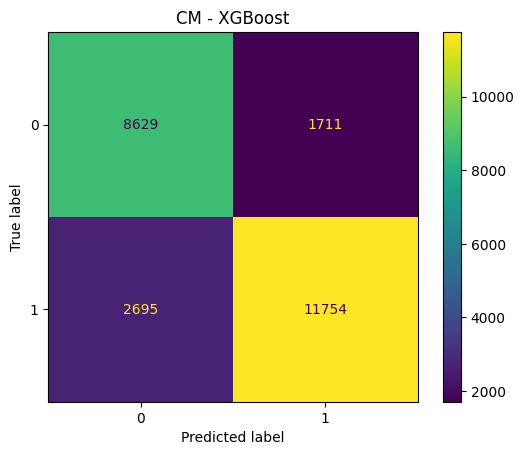

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm).plot()
plt.title("CM - XGBoost")
plt.show()

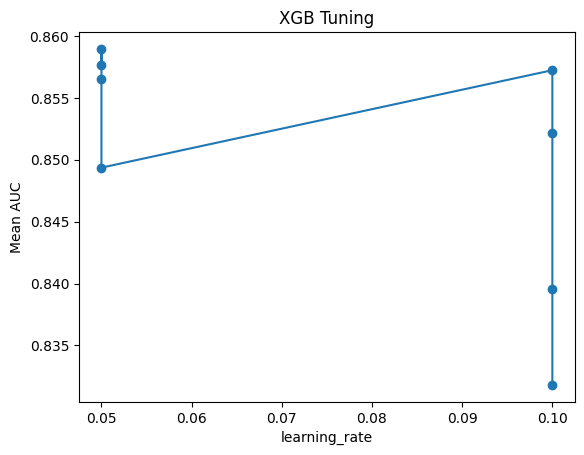

In [ ]:
results_xgb = pd.DataFrame(grid_xgb.cv_results_)

plt.figure()
plt.plot(results_xgb['param_learning_rate'], results_xgb['mean_test_score'], marker='o')

plt.xlabel("learning_rate")
plt.ylabel("Mean AUC")
plt.title("XGB Tuning")

plt.show()

catboost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

param_grid_cat = {
    'iterations': [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6]
}

grid_cat = GridSearchCV(
    CatBoostClassifier(verbose=0),
    param_grid_cat,
    cv=gkf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_cat.fit(X_train, y_train, groups=groups)

print("Best Params:", grid_cat.best_params_)

Best Params: {'depth': 4, 'iterations': 100, 'learning_rate': 0.05}


In [ ]:
best_cat = grid_cat.best_estimator_

y_pred_cat = best_cat.predict(X_test)
y_prob_cat = best_cat.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("AUC:", roc_auc_score(y_test, y_prob_cat))
print("Log Loss:", log_loss(y_test, y_prob_cat))

Accuracy: 0.8118520311428457
AUC: 0.9076365005817166
Log Loss: 0.39765502168555494


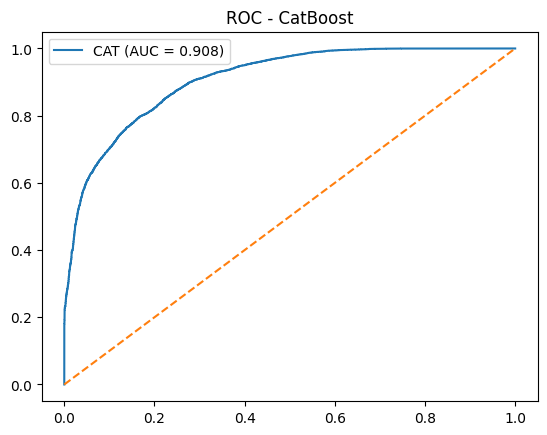

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_cat)
auc_score = roc_auc_score(y_test, y_prob_cat)

plt.figure()
plt.plot(fpr, tpr, label=f'CAT (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC - CatBoost")
plt.show()

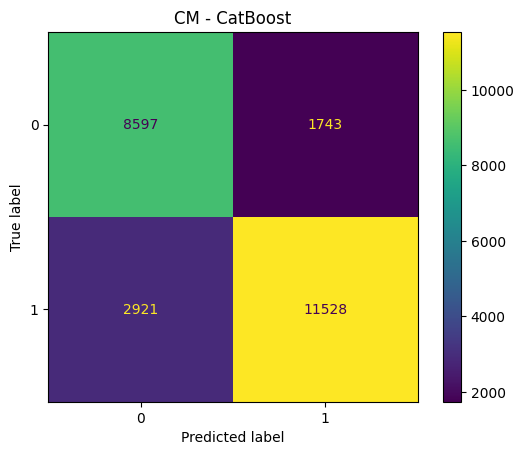

In [ ]:
cm = confusion_matrix(y_test, y_pred_cat)
ConfusionMatrixDisplay(cm).plot()
plt.title("CM - CatBoost")
plt.show()

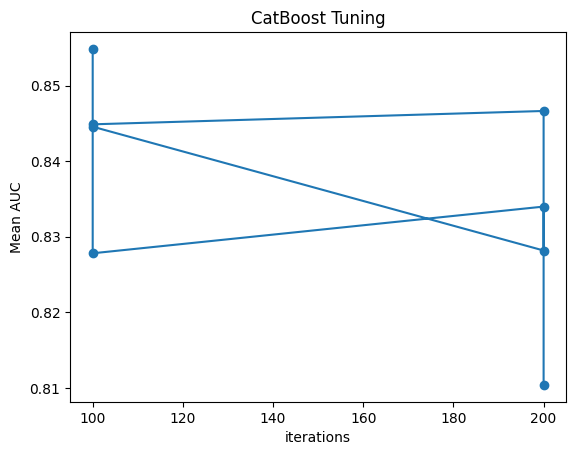

In [ ]:
results_cat = pd.DataFrame(grid_cat.cv_results_)

plt.figure()
plt.plot(results_cat['param_iterations'], results_cat['mean_test_score'], marker='o')

plt.xlabel("iterations")
plt.ylabel("Mean AUC")
plt.title("CatBoost Tuning")

plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Predictions already thakar kotha (check kor)
# LR
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:,1]

# RF
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# GB
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:,1]

# XGB
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

# CAT
y_pred_cat = best_cat.predict(X_test)
y_prob_cat = best_cat.predict_proba(X_test)[:,1]

# Table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_cat)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_cat)
    ],
    'Log Loss': [
        log_loss(y_test, y_prob_lr),
        log_loss(y_test, y_prob_rf),
        log_loss(y_test, y_prob_gb),
        log_loss(y_test, y_prob_xgb),
        log_loss(y_test, y_prob_cat)
    ]
})

# Sort by best AUC
print(results.sort_values(by='AUC', ascending=False))

                 Model  Accuracy       AUC  Log Loss
2    Gradient Boosting  0.819154  0.912631  0.397817
3              XGBoost  0.822260  0.910430  0.389955
4             CatBoost  0.811852  0.907637  0.397655
1        Random Forest  0.811449  0.905181  0.401273
0  Logistic Regression  0.810884  0.898834  0.405705


important feature


In [ ]:
import pandas as pd

# Feature importance
importances = best_xgb.feature_importances_

feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp.head(6))

                                     Feature  Importance
4                          required_run_rate    0.276519
5                                   pressure    0.082409
25  batting_team_Royal Challengers Bangalore    0.033519
7                              runs_required    0.030655
1                             wickets_fallen    0.029666
14               batting_team_Gujarat Titans    0.029347


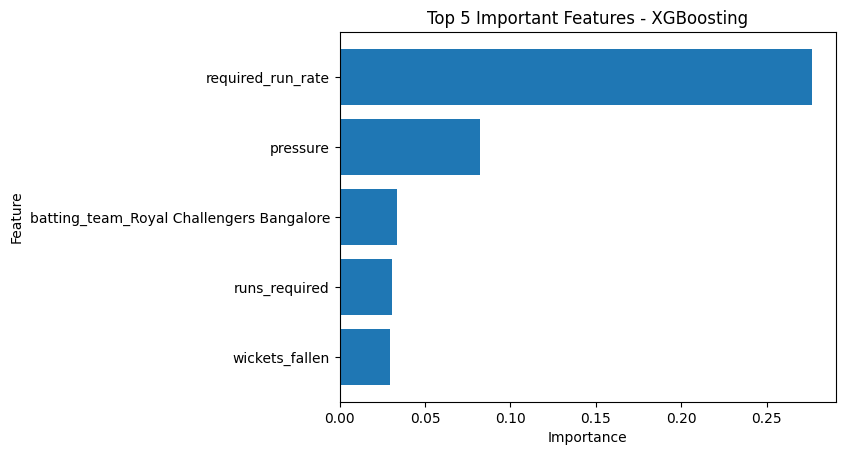

In [ ]:
import matplotlib.pyplot as plt

top6 = feat_imp.head(5)

plt.figure()
plt.barh(top6['Feature'], top6['Importance'])
plt.gca().invert_yaxis()

plt.title("Top 5 Important Features - XGBoosting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

prob curve

In [ ]:

valid_match_ids = data.loc[model_data.index, 'match_id'].unique()


match_id = valid_match_ids[0]   # try 1,2,3,4...


match_idx = data[(data['match_id'] == match_id) & (data.index.isin(model_data.index))].index

match_df = model_data.loc[match_idx].copy()

match_info = data.loc[match_idx]

batting_team = match_info['batting_team'].iloc[0]
bowling_team = match_info['bowling_team'].iloc[0]
winner = match_info['result'].iloc[-1]

# predict
X_match = match_df.drop(['result'], axis=1)
match_df['win_probability'] = best_gb.predict_proba(X_match)[:,1]

In [ ]:
# difference diye wicket detect
match_df['wicket'] = match_df['wickets_fallen'].diff().fillna(0)

# jekhane wicket poreche
wicket_points = match_df[match_df['wicket'] > 0]

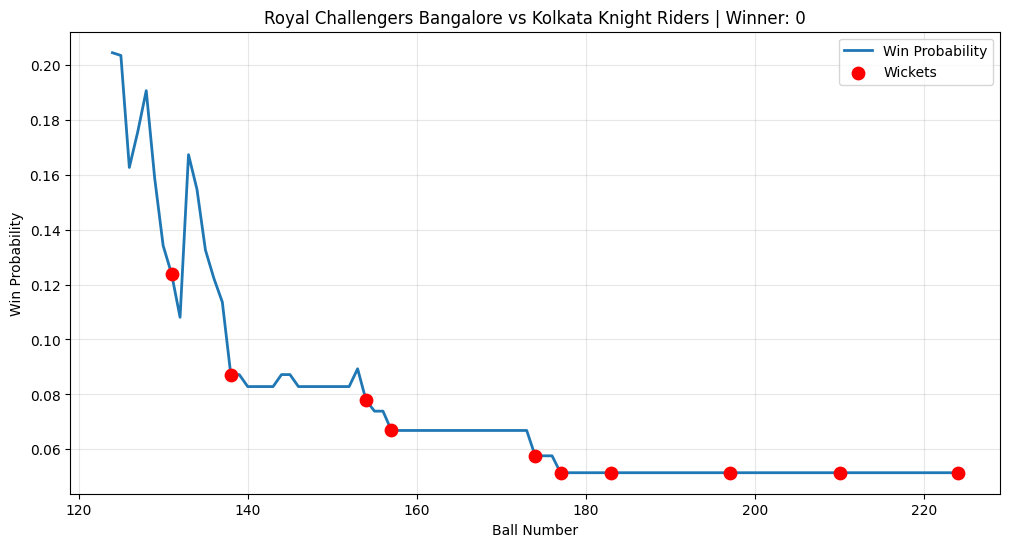

Text(0.5, 1.0, 'Match ID: 335982\nRoyal Challengers Bangalore vs Kolkata Knight Riders\nChasing: Royal Challengers Bangalore\nFinal Score: 82 | Runs Left: 141.0\nWinner: 0')

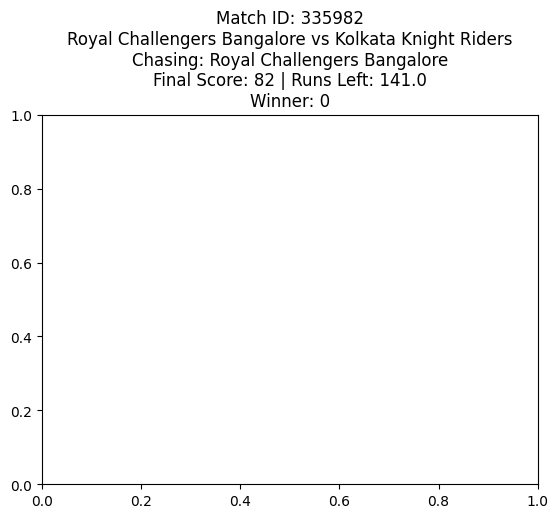

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Smooth line
plt.plot(match_df['win_probability'], linewidth=2, label='Win Probability')

# Wicket points highlight
plt.scatter(
    wicket_points.index,
    wicket_points['win_probability'],
    color='red',
    s=80,
    label='Wickets',
    zorder=5
)

# Title with info
plt.title(f"{batting_team} vs {bowling_team} | Winner: {winner}")

plt.xlabel("Ball Number")
plt.ylabel("Win Probability")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Extra info add
match_number = match_id

batting_team = match_info['batting_team'].iloc[0]
bowling_team = match_info['bowling_team'].iloc[0]

# Who is chasing (2nd innings batting team)
chasing_team = batting_team

# Final score info
final_row = match_df.iloc[-1]

final_score = final_row['current_score']
runs_required = final_row['runs_required']

winner = match_info['result'].iloc[-1]
title = f"""Match ID: {match_number}
{batting_team} vs {bowling_team}
Chasing: {chasing_team}
Final Score: {final_score} | Runs Left: {runs_required}
Winner: {winner}"""

plt.title(title)

In [ ]:
import pandas as pd

# 👉 simple input
current_score = 125
wickets_fallen = 8
over = 14
ball = 2
target = 160

batting_team = 'Mumbai Indians'
bowling_team = 'Royal Challengers Bangalore'

# 👉 basic calculation
balls_played = over * 6 + ball
balls_remaining = 120 - balls_played

runs_required = target - current_score
wickets_remaining = 10 - wickets_fallen

current_run_rate = current_score / balls_played * 6
required_run_rate = runs_required / balls_remaining * 6

pressure = runs_required / (balls_remaining + 1)

# phase
if balls_remaining > 90:
    match_phase = 'powerplay'
elif balls_remaining > 30:
    match_phase = 'middle'
else:
    match_phase = 'death'

# 👉 dataframe
custom_data = pd.DataFrame([{
    'batting_team': batting_team,
    'bowling_team': bowling_team,
    'current_score': current_score,
    'wickets_fallen': wickets_fallen,
    'wickets_remaining': wickets_remaining,
    'current_run_rate': current_run_rate,
    'required_run_rate': required_run_rate,
    'pressure': pressure,
    'balls_remaining': balls_remaining,
    'runs_required': runs_required,
    'match_phase': match_phase
}])

# 👉 encoding
custom_data = pd.get_dummies(custom_data)
custom_data = custom_data.reindex(columns=X_train.columns, fill_value=0)

# 👉 prediction
win_prob1 = best_gb.predict_proba(custom_data)[:,1][0]


print(f"Win Probability: {win_prob1:.2f}")

Win Probability: 0.72


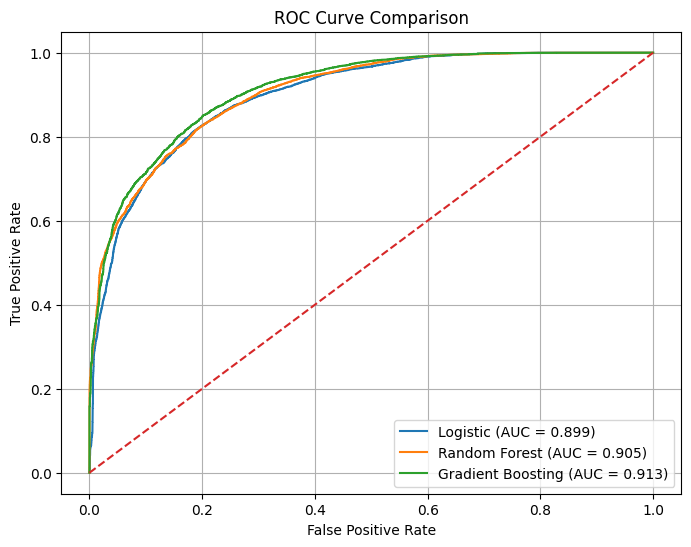

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 👉 probabilities
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

# 👉 ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# 👉 AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

# 👉 plot
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')

# diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()

plt.show()

In [ ]:
from sklearn.metrics import brier_score_loss

brier_lr = brier_score_loss(y_test, y_prob_lr)
brier_rf = brier_score_loss(y_test, y_prob_rf)
brier_gb = brier_score_loss(y_test, y_prob_gb)
brier_xgb = brier_score_loss(y_test, y_prob_xgb)
brier_cat = brier_score_loss(y_test, y_prob_cat)

print("LR:", brier_lr)
print("RF:", brier_rf)
print("GB:", brier_gb)
print("XGB:", brier_xgb)
print("CAT:", brier_cat)

LR: 0.1301905016639975
RF: 0.12898127743644586
GB: 0.12533249098477323
XGB: 0.12436858457360973
CAT: 0.12723644234589696


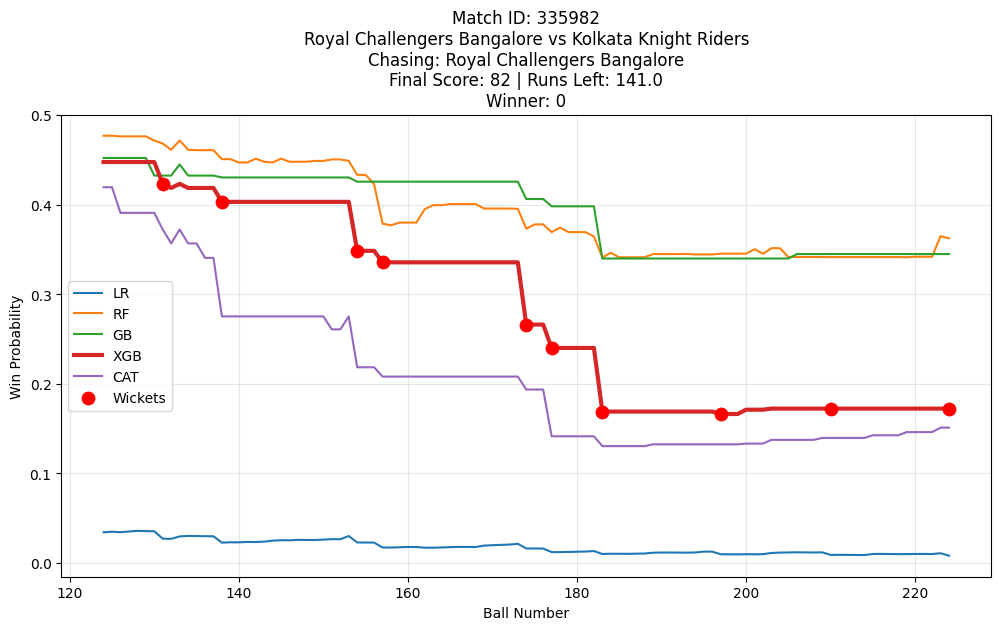

In [ ]:
import matplotlib.pyplot as plt

# ===== PREPARE X_match FOR PREDICTION =====
# match_df is already a copy of model_data for a specific match.
# It contains 'result' and all one-hot encoded features.

# First, drop the 'result' column as models were trained on X without 'result'.
X_match_prepared = match_df.drop('result', axis=1, errors='ignore')

# Then, drop the highly correlated columns that were removed from the training data (X)
columns_to_drop_from_X = ['wickets_remaining', 'pressure', 'balls_remaining', 'runs_required', 'match_phase_powerplay']
X_match_prepared = X_match_prepared.drop(columns=columns_to_drop_from_X, errors='ignore')

# Ensure X_match_prepared has the exact same columns and order as X_train
# (which reflects the final X after all drops and dummy creation).
# This is crucial to align with the trained model's expected feature order and presence.
X_match = X_match_prepared.reindex(columns=X_train.columns, fill_value=0)


# ===== CREATE PROBABILITIES (VERY IMPORTANT) =====
# Correct model variable names from lr, rf, gb, xgb, cat to best_lr, best_rf, etc.
match_df['lr_prob'] = best_lr.predict_proba(X_match)[:,1]
match_df['rf_prob'] = best_rf.predict_proba(X_match)[:,1]
match_df['gb_prob'] = best_gb.predict_proba(X_match)[:,1]
match_df['xgb_prob'] = best_xgb.predict_proba(X_match)[:,1]
match_df['cat_prob'] = best_cat.predict_proba(X_match)[:,1]

# ===== PLOT =====
plt.figure(figsize=(12,6))

plt.plot(match_df['lr_prob'], label='LR')
plt.plot(match_df['rf_prob'], label='RF')
plt.plot(match_df['gb_prob'], label='GB')
plt.plot(match_df['xgb_prob'], linewidth=3, label='XGB')
plt.plot(match_df['cat_prob'], label='CAT')

# Add wicket markers
plt.scatter(
    wicket_points.index,
    match_df.loc[wicket_points.index, 'xgb_prob'], # Use XGBoost probability for wicket marker Y-position
    color='red',
    s=80,
    label='Wickets',
    zorder=5
)

# ===== MATCH INFO =====
match_number = match_id

batting_team = match_info['batting_team'].iloc[0]
bowling_team = match_info['bowling_team'].iloc[0]

chasing_team = batting_team

final_row = match_df.iloc[-1]
final_score = final_row['current_score']
runs_required_for_title = final_row['runs_required']

winner = match_info['result'].iloc[-1]

title = f"""Match ID: {match_number}
{batting_team} vs {bowling_team}
Chasing: {chasing_team}
Final Score: {final_score} | Runs Left: {runs_required_for_title}
Winner: {winner}"""

plt.title(title)

plt.xlabel("Ball Number")
plt.ylabel("Win Probability")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
import numpy as np
import pandas as pd

# ===== INPUT (CHANGE AS YOU WANT) =====
current_score = 125
wickets_fallen = 8
overs = 14.2
target = 160

batting_team = 'Chennai Super Kings'
bowling_team = 'Mumbai Indians'

# ===== CONVERT OVERS TO BALLS =====
balls_played = int(overs) * 6 + int((overs - int(overs)) * 10)
balls_remaining = 120 - balls_played

# ===== CALCULATE FEATURES =====
runs_required = target - current_score
wickets_remaining = 10 - wickets_fallen

crr = (current_score / balls_played) * 6 if balls_played != 0 else 0
rrr = (runs_required / balls_remaining) * 6 if balls_remaining != 0 else 0

# Match phase calculation (used for one-hot encoding)
def get_phase(over):
    if over < 6:
        return 'powerplay'
    elif over < 15:
        return 'middle'
    else:
        return 'death'
match_phase = get_phase(int(overs)) # Use the integer part of overs for phase determination

# ===== CREATE DATAFRAME FOR CUSTOM INPUT =====
# Create a DataFrame with the *base* features that went into model_data before correlation removal
custom_input_df = pd.DataFrame([{
    'batting_team': batting_team,
    'bowling_team': bowling_team,
    'current_score': current_score,
    'wickets_fallen': wickets_fallen,
    'wickets_remaining': wickets_remaining, # Will be dropped later if in `columns_to_drop_from_X`
    'current_run_rate': crr,
    'required_run_rate': rrr,
    'pressure': runs_required / (balls_remaining + 1), # Will be dropped later if in `columns_to_drop_from_X`
    'balls_remaining': balls_remaining, # Will be dropped later if in `columns_to_drop_from_X`
    'runs_required': runs_required, # Will be dropped later if in `columns_to_drop_from_X`
    'match_phase': match_phase,
    'target': target
}])

# ===== ONE-HOT ENCODING AND ALIGNMENT =====
# Apply one-hot encoding
custom_input_df_encoded = pd.get_dummies(custom_input_df)

# Reindex to align with X_train.columns and fill missing with 0
# This ensures the same number and order of features as the training data
X_custom_prepared = custom_input_df_encoded.reindex(columns=X_train.columns, fill_value=0)

# ===== PREDICTIONS =====
lr_p  = best_lr.predict_proba(X_custom_prepared)[0][1]
rf_p  = best_rf.predict_proba(X_custom_prepared)[0][1]
gb_p  = best_gb.predict_proba(X_custom_prepared)[0][1]
xgb_p = best_xgb.predict_proba(X_custom_prepared)[0][1]
cat_p = best_cat.predict_proba(X_custom_prepared)[0][1]

# ===== PRINT OUTPUT =====
print("Win Probability (Custom Scenario):\n")
print(f"Logistic Regression : {lr_p:.3f}")
print(f"Random Forest       : {rf_p:.3f}")
print(f"Gradient Boosting   : {gb_p:.3f}")
print(f"XGBoost             : {xgb_p:.3f}")
print(f"CatBoost            : {cat_p:.3f}")

Win Probability (Custom Scenario):

Logistic Regression : 0.223
Random Forest       : 0.522
Gradient Boosting   : 0.668
XGBoost             : 0.673
CatBoost            : 0.817


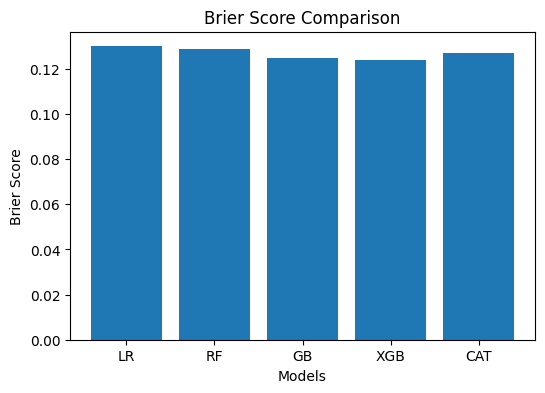

In [ ]:
import matplotlib.pyplot as plt

models = ['LR','RF','GB','XGB','CAT']
scores = [0.130,0.129,0.125,0.124,0.127]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("Brier Score")
plt.title("Brier Score Comparison")

plt.show()

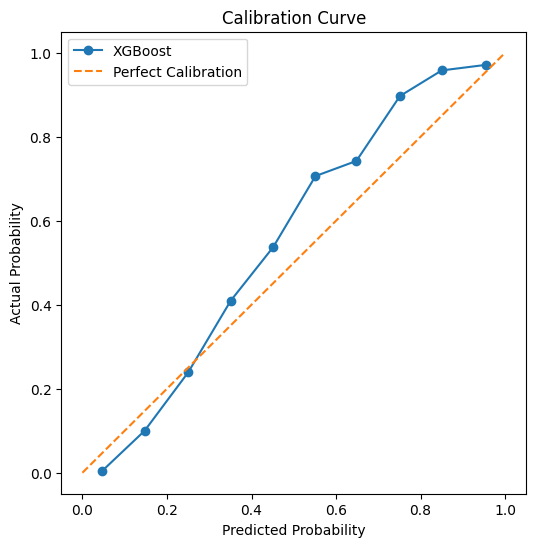

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# XGBoost calibration
prob_true, prob_pred = calibration_curve(
    y_test,
    best_xgb.predict_proba(X_test)[:,1],
    n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0,1],[0,1],'--', label='Perfect Calibration')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")

plt.legend()
plt.show()

In [ ]:
# copy test data
errors = X_test.copy()

# add actual & predicted
errors['actual'] = y_test.values
errors['pred'] = best_xgb.predict(X_test)

# wrong predictions
wrong = errors[errors['actual'] != errors['pred']]

print("Total wrong predictions:", len(wrong))

Total wrong predictions: 4406


In [ ]:
wrong[['required_run_rate','wickets_fallen','balls_remaining','runs_required']].describe()

,required_run_rate,wickets_fallen,balls_remaining,runs_required
count,4406.000000,4406.000000,4406.000000,4406.000000
mean,9.311822,1.912846,75.815252,111.706537
std,2.182176,1.773594,31.623608,43.714858
min,2.000000,0.000000,1.000000,3.000000
25%,8.093023,0.000000,52.000000,81.000000
50%,9.054545,2.000000,81.000000,116.000000
75%,10.133019,3.000000,104.000000,146.000000
max,32.000000,9.000000,119.000000,208.000000


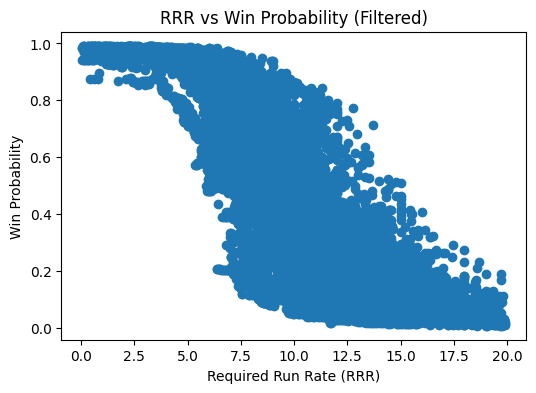

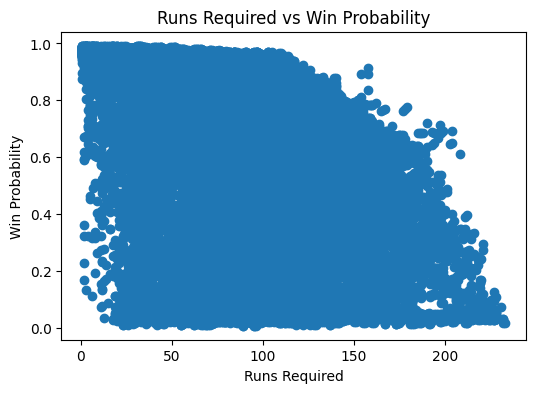

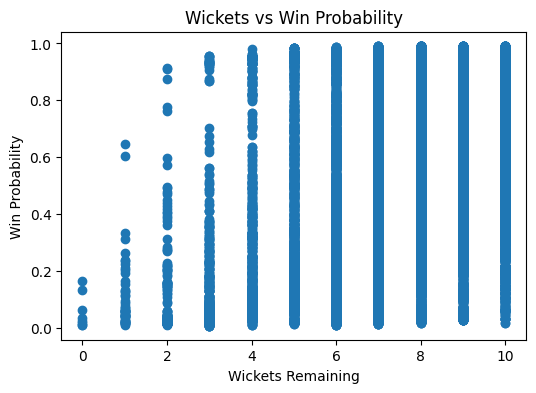

In [ ]:
import matplotlib.pyplot as plt

# ===== COPY DATA =====
filtered = X_test.copy()

# ===== CLEAN DATA =====
# remove invalid RRR
filtered = filtered[(filtered['required_run_rate'] > 0) & (filtered['required_run_rate'] < 20)]

# remove negative runs
filtered = filtered[filtered['runs_required'] >= 0]

# remove invalid wickets (optional safety)
filtered = filtered[(filtered['wickets_remaining'] >= 0) & (filtered['wickets_remaining'] <= 10)]

# ===== PROBABILITY =====
probs = best_xgb.predict_proba(filtered)[:,1]

# ===== PLOT 1: RRR vs Probability =====
plt.figure(figsize=(6,4))
plt.scatter(filtered['required_run_rate'], probs)
plt.xlabel("Required Run Rate (RRR)")
plt.ylabel("Win Probability")
plt.title("RRR vs Win Probability (Filtered)")
plt.show()

# ===== PLOT 2: Runs Left vs Probability =====
plt.figure(figsize=(6,4))
plt.scatter(filtered['runs_required'], probs)
plt.xlabel("Runs Required")
plt.ylabel("Win Probability")
plt.title("Runs Required vs Win Probability")
plt.show()

# ===== PLOT 3: Wickets vs Probability =====
plt.figure(figsize=(6,4))
plt.scatter(filtered['wickets_remaining'], probs)
plt.xlabel("Wickets Remaining")
plt.ylabel("Win Probability")
plt.title("Wickets vs Win Probability")
plt.show()

In [ ]:
import pandas as pd

# ===== FUNCTION: CUSTOM PREDICTION =====
def predict_win_probability(
    runs_remaining,
    balls_remaining,
    wickets_fallen,
    current_score,
    target,
    batting_team,
    bowling_team
):

    # ===== DERIVED FEATURES =====
    balls_played = 120 - balls_remaining

    current_run_rate = current_score / (balls_played/6) if balls_played > 0 else 0
    required_run_rate = (runs_remaining / (balls_remaining/6)) if balls_remaining > 0 else 0

    # The 'pressure' feature was removed in the correlation analysis and should not be re-introduced here.
    # However, if we need to keep the function signature and custom_input structure,
    # we should pass a default value or calculate it if it's still intended to be used
    # in the model that was trained with it.
    # Given the X_train columns don't include 'pressure' after dropping, this line might be problematic.
    # Let's check X_train.columns to be sure.
    # Based on the X_train kernel state, 'pressure' is NOT in X_train.columns.
    # So we should remove 'pressure' from custom_input.

    # Calculate overs to determine match phase
    overs_played = balls_played / 6
    def get_phase(over):
        if over < 6:
            return 'powerplay'
        elif over < 15:
            return 'middle'
        else:
            return 'death'
    match_phase = get_phase(overs_played)

    # ===== BASE INPUT =====
    custom_input = {
        'current_score': current_score,
        'wickets_fallen': wickets_fallen,
        'current_run_rate': current_run_rate,
        'required_run_rate': required_run_rate,
        # 'pressure': pressure, # Removed as per feature selection
        'target': target # Target was kept for the model_data
    }

    # Convert to DataFrame to handle one-hot encoding
    X_custom = pd.DataFrame([custom_input])

    # Add match phase for one-hot encoding
    X_custom['match_phase'] = match_phase

    # Apply one-hot encoding for categorical features
    X_custom = pd.get_dummies(X_custom)

    # ===== MATCH TRAINING COLUMNS =====
    # Reindex to align with X_train.columns and fill missing with 0
    # This ensures the same number and order of features as the training data
    # X_train.columns already has the highly correlated features dropped.
    X_custom = X_custom.reindex(columns=X_train.columns, fill_value=0)

    # ===== PREDICTIONS =====
    results = {
        "Logistic Regression": best_lr.predict_proba(X_custom)[0][1],
        "Random Forest": best_rf.predict_proba(X_custom)[0][1],
        "Gradient Boosting": best_gb.predict_proba(X_custom)[0][1],
        "XGBoost": best_xgb.predict_proba(X_custom)[0][1],
        "CatBoost": best_cat.predict_proba(X_custom)[0][1]
    }

    # ===== PRINT OUTPUT =====
    print("\n===== WIN PROBABILITY =====")
    print(f"Match: {batting_team} (Chasing) vs {bowling_team}\n")

    for model, prob in results.items():
        print(f"{model}: {prob:.3f}")

    return results

In [ ]:
predict_win_probability(
    runs_remaining=30,
    balls_remaining=12,
    wickets_fallen=5,
    current_score=150,
    target=180,
    batting_team="Royal Challengers Bangalore",
    bowling_team="Kolkata Knight Riders"
)


===== WIN PROBABILITY =====
Match: Royal Challengers Bangalore (Chasing) vs Kolkata Knight Riders

Logistic Regression: 0.244
Random Forest: 0.570
Gradient Boosting: 0.594
XGBoost: 0.711
CatBoost: 0.454


{'Logistic Regression': np.float64(0.24374980197457838),
 'Random Forest': np.float64(0.569762960495955),
 'Gradient Boosting': np.float64(0.5937118593213639),
 'XGBoost': np.float32(0.7111762),
 'CatBoost': np.float64(0.4540583382976383)}

In [ ]:
predict_win_probability(
    runs_remaining=30,
    balls_remaining=12,
    wickets_fallen=,
    current_score=150,
    target=180,
    batting_team="Chennai Super Kings",
    bowling_team="Kolkata Knight Riders"
)


===== WIN PROBABILITY =====
Match: Chennai Super Kings (Chasing) vs Kolkata Knight Riders

Logistic Regression: 0.097
Random Forest: 0.499
Gradient Boosting: 0.515
XGBoost: 0.572
CatBoost: 0.392


{'Logistic Regression': np.float64(0.09709056906122754),
 'Random Forest': np.float64(0.4990022650166924),
 'Gradient Boosting': np.float64(0.5147719622395039),
 'XGBoost': np.float32(0.5715853),
 'CatBoost': np.float64(0.39220772721843944)}